In [2]:
import numpy as np 
import pandas as pd 
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
       		 print(os.path.join(dirname, filename))


In [3]:
# import numpy as np
# import pandas as pd
# from pathlib import Path
# import os.path
# import matplotlib.pyplot as plt
# import tensorflow as tf
# from tensorflow.keras.preprocessing.image import load_img,img_to_array
# print(tf.__version__)
import numpy as np
import pandas as pd
import os
from pathlib import Path
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array

print(tf.__version__)


2.17.0


In [3]:
!pip install tensorflow


     ---------------------------------------- 0.0/48.7 kB ? eta -:--:--
     ---------------------------------------- 48.7/48.7 kB 2.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/385.0 MB ? eta -:--:--
   ---------------------------------------- 0.4/385.0 MB 12.2 MB/s eta 0:00:32
   ---------------------------------------- 0.8/385.0 MB 8.8 MB/s eta 0:00:44
   ---------------------------------------- 1.2/385.0 MB 8.3 MB/s eta 0:00:47
   ---------------------------------------- 1.4/385.0 MB 9.8 MB/s eta 0:00:40
   ---------------------------------------- 1.5/385.0 MB 6.3 MB/s eta 0:01:01
   ---------------------------------------- 1.9/385.0 MB 6.9 MB/s eta 0:00:56
   ---------------------------------------- 2.4/385.0 MB 7.6 MB/s eta 0:00:51
   ---------------------------------------- 3.0/385.0 MB 7.9 MB/s eta 0:00:49
   ---------------------------------------- 3.3/385.0 MB 8.1 MB/s eta 0:00:47
   ---------------------------------------- 3.7/385.0 MB 8.1 MB/s eta 0:00

In [4]:
# from pathlib import Path

# # Define directories using raw strings to avoid escape character issues
# train_dir = Path(r'C:\Users\mas_r\OneDrive\Desktop\Major project\Dataset\train')
# train_filepaths = list(train_dir.glob(r'**/*.jpg'))

# test_dir = Path(r'C:\Users\mas_r\OneDrive\Desktop\Major project\Dataset\test')
# test_filepaths = list(test_dir.glob(r'**/*.jpg'))

# val_dir = Path(r'C:\Users\mas_r\OneDrive\Desktop\Major project\Dataset\validation')
# val_filepaths = list(val_dir.glob(r'**/*.jpg'))  # Corrected from test_dir to val_dir
# Define directories using raw strings to avoid escape character issues
train_dir = Path(r'C:\Users\mas_r\OneDrive\Desktop\Major project\Dataset\train')
train_filepaths = list(train_dir.glob(r'**/*.jpg'))

test_dir = Path(r'C:\Users\mas_r\OneDrive\Desktop\Major project\Dataset\test')
test_filepaths = list(test_dir.glob(r'**/*.jpg'))

val_dir = Path(r'C:\Users\mas_r\OneDrive\Desktop\Major project\Dataset\validation')
val_filepaths = list(val_dir.glob(r'**/*.jpg'))


In [5]:
# import pandas as pd
# from pathlib import Path

# def image_processing(filepath):
#     """Create a DataFrame with the filepath and the labels of the pictures."""
    
#     # Extract labels using Path to handle file paths correctly
#     labels = [Path(fp).parts[-2] for fp in filepath]
    
#     # Create DataFrame from filepaths and labels
#     filepath_series = pd.Series(filepath, name='Filepath').astype(str)
#     labels_series = pd.Series(labels, name='Label')
    
#     # Combine into a DataFrame
#     df = pd.concat([filepath_series, labels_series], axis=1)
    
#     # Shuffle the DataFrame
#     df = df.sample(frac=1).reset_index(drop=True)
    
#     return df

# # Process the filepaths for train, test, and validation sets
# train_df = image_processing(train_filepaths)
# test_df = image_processing(test_filepaths)
# val_df = image_processing(val_filepaths)

# # Print some details about the training set
# print('-- Training set --\n')
# print(f'Number of pictures: {train_df.shape[0]}\n')
# print(f'Number of different labels: {len(train_df.Label.unique())}\n')
# print(f'Labels: {train_df.Label.unique()}')
def image_processing(filepath):
    """Create a DataFrame with the filepath and the labels of the pictures."""
    labels = [Path(fp).parts[-2] for fp in filepath]
    filepath_series = pd.Series(filepath, name='Filepath').astype(str)
    labels_series = pd.Series(labels, name='Label')
    df = pd.concat([filepath_series, labels_series], axis=1).sample(frac=1).reset_index(drop=True)
    return df

# Process the filepaths for train, test, and validation sets
train_df = image_processing(train_filepaths)
test_df = image_processing(test_filepaths)
val_df = image_processing(val_filepaths)


In [6]:
# df_unique = train_df.copy().drop_duplicates(subset=["Label"]).reset_index()
# fig, axes = plt.subplots(nrows=6, ncols=6, figsize=(8, 7),
#                         subplot_kw={'xticks': [], 'yticks': []})
# for i, ax in enumerate(axes.flat):
#     ax.imshow(plt.imread(df_unique.Filepath[i]))
#     ax.set_title(df_unique.Label[i], fontsize = 12)
# plt.tight_layout(pad=0.5)
# plt.show()

# train_generator = tf.keras.preprocessing.image.ImageDataGenerator(
#     preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input)
# test_generator = tf.keras.preprocessing.image.ImageDataGenerator(
#     preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input)
# train_images = train_generator.flow_from_dataframe(
#     dataframe=train_df,
#     x_col='Filepath',
#     y_col='Label',
#     target_size=(224, 224),
#     color_mode='rgb',
#     class_mode='categorical',
#     batch_size=32,
#     shuffle=True,
#     seed=0,
#     rotation_range=30,
#     zoom_range=0.15,
#     width_shift_range=0.2,
#     height_shift_range=0.2,
#     shear_range=0.15,
#     horizontal_flip=True,
#     fill_mode="nearest"
# )
# Data Generators
train_generator = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input,
    rotation_range=30,
    zoom_range=0.15,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    horizontal_flip=True,
    fill_mode="nearest"
)
val_generator = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input
)

train_images = train_generator.flow_from_dataframe(
    dataframe=train_df,
    x_col='Filepath',
    y_col='Label',
    target_size=(224, 224),
    class_mode='categorical',
    batch_size=32,
    shuffle=True,
    seed=0
)

val_images = val_generator.flow_from_dataframe(
    dataframe=val_df,
    x_col='Filepath',
    y_col='Label',
    target_size=(224, 224),
    class_mode='categorical',
    batch_size=32,
    shuffle=True,
    seed=0
)

Found 2855 validated image filenames belonging to 36 classes.
Found 340 validated image filenames belonging to 36 classes.


In [14]:
# val_images = train_generator.flow_from_dataframe(
#     dataframe=val_df,
#     x_col='Filepath',
#     y_col='Label',
#     target_size=(224, 224),
#     color_mode='rgb',
#     class_mode='categorical',
#     batch_size=32,
#     shuffle=True,
#     seed=0,
#     rotation_range=30,
#     zoom_range=0.15,
#     width_shift_range=0.2,
#     height_shift_range=0.2,
#     shear_range=0.15,
#     horizontal_flip=True,
#     fill_mode="nearest"
# )
# Load Pretrained Models
# Define MobileNetV2 model
mobilenet_base = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet',
    pooling='avg'
)
mobilenet_base.trainable = False

inputs_mobilenet = mobilenet_base.input
x_mobilenet = tf.keras.layers.Dense(128, activation='relu')(mobilenet_base.output)
x_mobilenet = tf.keras.layers.Dense(128, activation='relu')(x_mobilenet)
outputs_mobilenet = tf.keras.layers.Dense(len(train_df.Label.unique()), activation='softmax')(x_mobilenet)

model_mobilenet = tf.keras.Model(inputs=inputs_mobilenet, outputs=outputs_mobilenet)

model_mobilenet.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
# Define VGG16 model
vgg_base = tf.keras.applications.VGG16(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet',
    pooling='avg'
)
vgg_base.trainable = False

inputs_vgg = vgg_base.input
x_vgg = tf.keras.layers.Dense(128, activation='relu')(vgg_base.output)
x_vgg = tf.keras.layers.Dense(128, activation='relu')(x_vgg)
outputs_vgg = tf.keras.layers.Dense(len(train_df.Label.unique()), activation='softmax')(x_vgg)

model_vgg = tf.keras.Model(inputs=inputs_vgg, outputs=outputs_vgg)

model_vgg.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [15]:
# val_images = train_generator.flow_from_dataframe(
#     dataframe=val_df,
#     x_col='Filepath',
#     y_col='Label',
#     target_size=(224, 224),
#     color_mode='rgb',
#     class_mode='categorical',
#     batch_size=32,
#     shuffle=True,
#     seed=0,
#     rotation_range=30,
#     zoom_range=0.15,
#     width_shift_range=0.2,
#     height_shift_range=0.2,
#     shear_range=0.15,
#     horizontal_flip=True,
#     fill_mode="nearest"
# )
# Input Layer
inputs = tf.keras.Input(shape=(224, 224, 3))

# Feature Extraction
vgg_features = vgg16_model(inputs)
mobilenet_features = mobilenet_model(inputs)

# Combine Features
combined_features = tf.keras.layers.Concatenate()([vgg_features, mobilenet_features])

# Fully Connected Layers
x = tf.keras.layers.Dense(256, activation='relu')(combined_features)
x = tf.keras.layers.Dropout(0.5)(x)
outputs = tf.keras.layers.Dense(len(train_df.Label.unique()), activation='softmax')(x)

# Model
model = tf.keras.Model(inputs=inputs, outputs=outputs)

# Compile Model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [9]:
# pretrained_model = tf.keras.applications.MobileNetV2(
#     input_shape=(224, 224, 3),
#     include_top=False,
#     weights='imagenet',
#     pooling='avg'
# )
# pretrained_model.trainable = False

# inputs = pretrained_model.input

# x = tf.keras.layers.Dense(128, activation='relu')(pretrained_model.output)
# x = tf.keras.layers.Dense(128, activation='relu')(x)

# outputs = tf.keras.layers.Dense(36, activation='softmax')(x)

# model = tf.keras.Model(inputs=inputs, outputs=outputs)

# model.compile(
#     optimizer='adam',
#     loss='categorical_crossentropy',
#     metrics=['accuracy']
# )
# history = model.fit(
#     train_images,
#     validation_data=val_images,
#     batch_size = 32,
#     epochs=5,
#     callbacks=[
#         tf.keras.callbacks.EarlyStopping(
#             monitor='val_loss',
#             patience=2,
#             restore_best_weights=True
#         )
#     ]
# )
# Train Model
history = model.fit(
    train_images,
    validation_data=val_images,
    epochs=5,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=2,
            restore_best_weights=True
        )
    ]
)

# Test Data Generator
test_generator = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input
)

test_images = test_generator.flow_from_dataframe(
    dataframe=test_df,
    x_col='Filepath',
    y_col='Label',
    target_size=(224, 224),
    class_mode='categorical',
    shuffle=False
)


Epoch 1/5


C:\Users\mas_r\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


90/90 ━━━━━━━━━━━━━━━━━━━━ 982s 10s/step - accuracy: 0.2879 - loss: 2.8238 - val_accuracy: 0.8235 - val_loss: 0.5906
Epoch 2/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 1399s 15s/step - accuracy: 0.6403 - loss: 1.1898 - val_accuracy: 0.8676 - val_loss: 0.4242
Epoch 3/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 806s 9s/step - accuracy: 0.7207 - loss: 0.9177 - val_accuracy: 0.8941 - val_loss: 0.3458
Epoch 4/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 848s 9s/step - accuracy: 0.7475 - loss: 0.7691 - val_accuracy: 0.9147 - val_loss: 0.2823
Epoch 5/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 696s 7s/step - accuracy: 0.7947 - loss: 0.6549 - val_accuracy: 0.9118 - val_loss: 0.2591
Found 340 validated image filenames belonging to 36 classes.


In [10]:
# from tensorflow.keras.preprocessing.image import ImageDataGenerator

# # Load test images
# test_datagen = ImageDataGenerator(rescale=1./255)

# test_dir = r"C:\Users\mas_r\OneDrive\Desktop\Major project\Dataset\test"
# test_images = test_datagen.flow_from_directory(
#     test_dir,
#     target_size=(224, 224),
#     batch_size=32,
#     class_mode='categorical',
#     shuffle=False
# )

# # Predict the labels of the test_images
# pred = model.predict(test_images)
# pred = np.argmax(pred, axis=1)

# # Map the labels
# labels = (train_images.class_indices)
# labels = dict((v, k) for k, v in labels.items())
# pred1 = [labels[k] for k in pred]

# def output(location):
#     img = load_img(location, target_size=(224, 224))
#     img = img_to_array(img)
#     img = img / 255.0
#     img = np.expand_dims(img, axis=0)
#     answer = model.predict(img)
#     y_class = answer.argmax(axis=-1)
#     res = labels[y_class[0]]  # Get the label
#     return res

# # Test the output function
# img_result = output(r"C:\Users\mas_r\OneDrive\Desktop\Major project\Dataset\test\cabbage\Image_1.jpg")
# print(img_result)

# # Save the model
# model.save('FV.h5')

# Predict
pred = model.predict(test_images)
pred = np.argmax(pred, axis=1)

# Map Labels
labels = (train_images.class_indices)
labels = dict((v, k) for k, v in labels.items())
predicted_labels = [labels[k] for k in pred]

# Function for Single Image Prediction
def predict_single_image(image_path):
    img = load_img(image_path, target_size=(224, 224))
    img = img_to_array(img)
    img = tf.keras.applications.mobilenet_v2.preprocess_input(img)
    img = np.expand_dims(img, axis=0)
    predictions = model.predict(img)
    predicted_class = np.argmax(predictions, axis=-1)
    return labels[predicted_class[0]]

# Test Prediction on a Single Image
img_result = predict_single_image(r"C:\Users\mas_r\OneDrive\Desktop\Major project\Dataset\test\cabbage\Image_1.jpg")
print(img_result)

# Save Model
model.save('combined_model.h5')


C:\Users\mas_r\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


11/11 ━━━━━━━━━━━━━━━━━━━━ 81s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


cabbage


Epoch 1/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 283s 3s/step - accuracy: 0.3484 - loss: 2.6141 - val_accuracy: 0.7912 - val_loss: 0.6336
Epoch 2/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 265s 3s/step - accuracy: 0.7366 - loss: 0.8166 - val_accuracy: 0.8941 - val_loss: 0.4133
Epoch 3/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 273s 3s/step - accuracy: 0.8138 - loss: 0.5737 - val_accuracy: 0.8824 - val_loss: 0.3766
Epoch 4/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 270s 3s/step - accuracy: 0.8345 - loss: 0.4833 - val_accuracy: 0.9176 - val_loss: 0.3277
Epoch 5/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 281s 3s/step - accuracy: 0.8752 - loss: 0.3868 - val_accuracy: 0.8912 - val_loss: 0.3071
Epoch 1/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 504s 5s/step - accuracy: 0.0929 - loss: 3.5049 - val_accuracy: 0.3382 - val_loss: 2.5814
Epoch 2/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 521s 6s/step - accuracy: 0.3203 - loss: 2.5641 - val_accuracy: 0.5882 - val_loss: 1.5950
Epoch 3/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 497s 5s/step - accuracy: 0.4906 - loss: 1.8495 - val_accuracy: 0.6471 - val_loss:

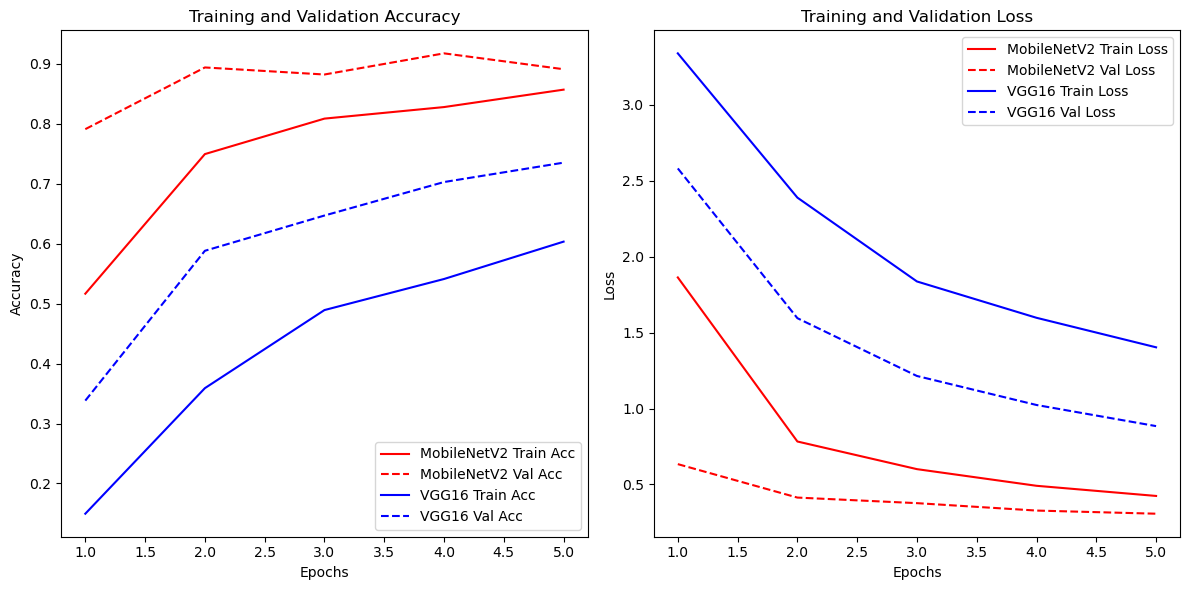

In [16]:
# Import necessary libraries
import matplotlib.pyplot as plt

# Function to plot accuracy and loss for comparison
def plot_comparison(history1, history2, model_names):
    # Extract metrics
    acc1 = history1.history['accuracy']
    val_acc1 = history1.history['val_accuracy']
    loss1 = history1.history['loss']
    val_loss1 = history1.history['val_loss']

    acc2 = history2.history['accuracy']
    val_acc2 = history2.history['val_accuracy']
    loss2 = history2.history['loss']
    val_loss2 = history2.history['val_loss']

    epochs = range(1, len(acc1) + 1)

    # Plot accuracy comparison
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc1, 'r-', label=f'{model_names[0]} Train Acc')
    plt.plot(epochs, val_acc1, 'r--', label=f'{model_names[0]} Val Acc')
    plt.plot(epochs, acc2, 'b-', label=f'{model_names[1]} Train Acc')
    plt.plot(epochs, val_acc2, 'b--', label=f'{model_names[1]} Val Acc')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot loss comparison
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss1, 'r-', label=f'{model_names[0]} Train Loss')
    plt.plot(epochs, val_loss1, 'r--', label=f'{model_names[0]} Val Loss')
    plt.plot(epochs, loss2, 'b-', label=f'{model_names[1]} Train Loss')
    plt.plot(epochs, val_loss2, 'b--', label=f'{model_names[1]} Val Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Train MobileNetV2
history_mobilenet = model_mobilenet.fit(
    train_images,
    validation_data=val_images,
    epochs=5,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=2,
            restore_best_weights=True
        )
    ]
)

# Train VGG16
history_vgg = model_vgg.fit(
    train_images,
    validation_data=val_images,
    epochs=5,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=2,
            restore_best_weights=True
        )
    ]
)

# Plot comparison of MobileNetV2 and VGG16
plot_comparison(history_mobilenet, history_vgg, ["MobileNetV2", "VGG16"])
